In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("Assets"):
    sub_folder_files = os.listdir(os.path.join("Assets", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 450
Kelas: ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']


In [4]:
def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape)
    return (image - min_val) / (max_val - min_val) * 255

def equalization(input_gambar):
    input_gambar = np.clip(input_gambar, 0, 255)
    input_gambar = input_gambar.astype(np.uint8)
    intensitas = np.zeros(256, dtype=int) 
    height, width = input_gambar.shape 
    
    for i in range(height):
        for j in range(width):
            bantu = int(input_gambar[i,j]) 
            intensitas[bantu] += 1

    cdf = np.zeros(256, dtype=int) 
    cdf[0] = intensitas[0]
    for i in range(256): 
        cdf[i] = np.sum(intensitas[0:i+1]) 

    hasil = np.round((cdf * 255) / (height * width)).astype(np.uint8)
    gambar_baru = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            pixel_lama = input_gambar[i, j]
            gambar_baru[i, j] = hasil[pixel_lama]

    return gambar_baru

In [6]:
size = (128, 128)
# P1 :Resize → Grayscale → Normalisasi → Histogram Equalization
def pre_proses(image, target_size=size):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    img = normalisasi(gray)
    img = equalization(img)

    return img

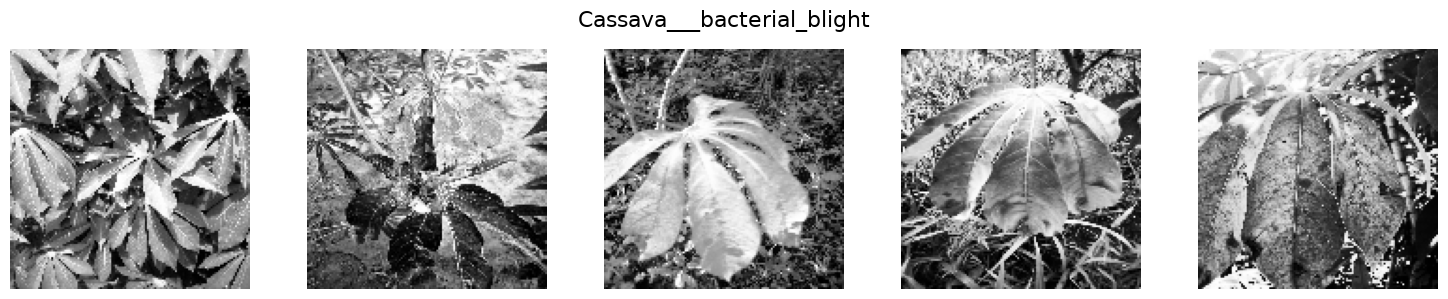

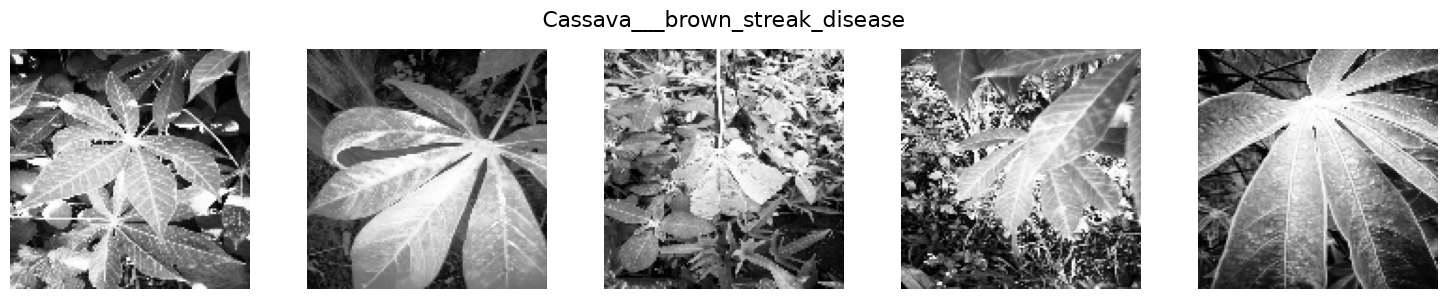

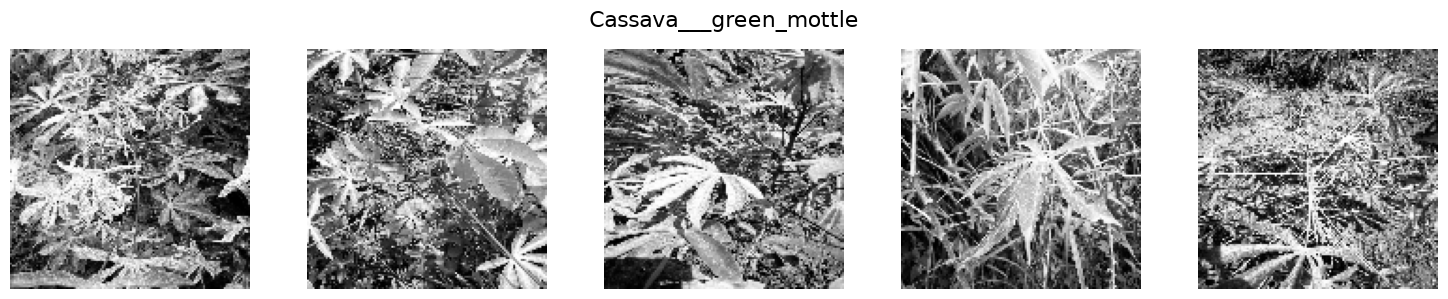

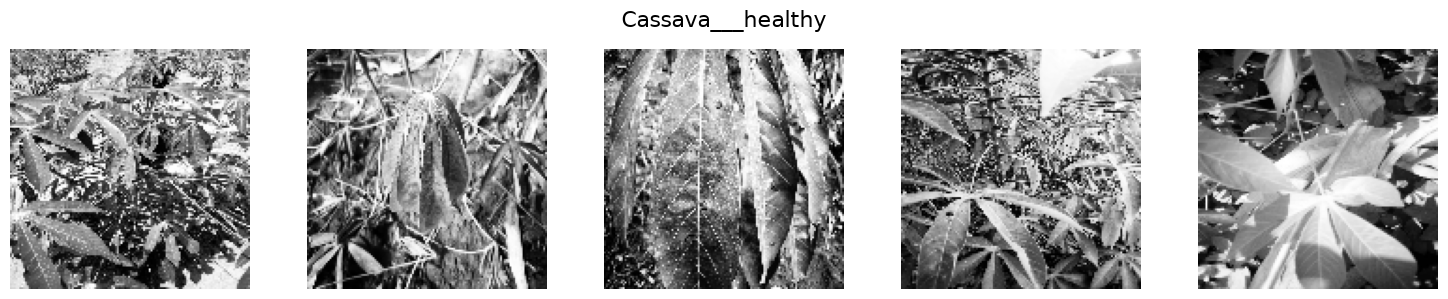

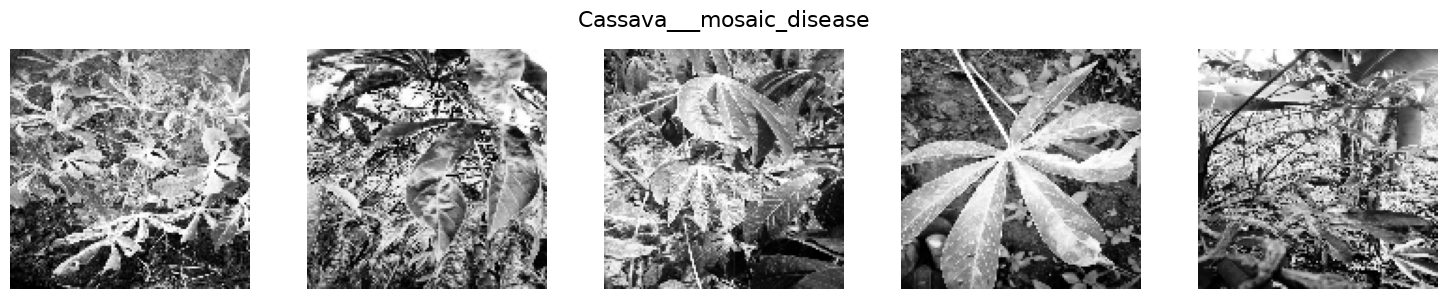

In [12]:
def percobaan1(img):
    hasil = pre_proses(img)
    return hasil

dataPreprocessed = [percobaan1(img) for img in data]
unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    fig, axs = plt.subplots(1, 5, figsize=(15, 3)) 
    fig.suptitle(label, fontsize=16)

    for k in range(5):
        ax = axs[k]
        
        if k < len(idxs):
            ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')

        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

In [13]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [14]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [15]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 450 citra.


In [17]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('./Hasil_ekstraksi/hasil_ekstraksi_Percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi_Percobaan1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Cassava___bacterial_blight_1.jpg,Cassava___bacterial_blight,2454.985113,3120.718271,2290.861836,3049.449005,0.079937,0.067299,0.077030,0.065407,...,0.000169,0.000143,0.012791,0.011880,0.012983,0.011945,0.773673,0.712950,0.788793,0.719511
1,Cassava___bacterial_blight_2.jpg,Cassava___bacterial_blight,2187.926366,2845.718705,2544.593135,3143.683179,0.059522,0.046502,0.050969,0.044905,...,0.000128,0.000119,0.011957,0.011113,0.011327,0.010895,0.798987,0.738653,0.766203,0.711281
2,Cassava___bacterial_blight_3.jpg,Cassava___bacterial_blight,1678.432579,2408.218054,1859.901267,2233.546345,0.087655,0.063783,0.075240,0.063821,...,0.000263,0.000231,0.017217,0.015230,0.016223,0.015190,0.846074,0.778950,0.829585,0.794997
3,Cassava___bacterial_blight_4.jpg,Cassava___bacterial_blight,2771.727793,3711.813318,3086.123155,3610.758572,0.073699,0.055561,0.068456,0.060416,...,0.000167,0.000153,0.013303,0.012004,0.012908,0.012365,0.744621,0.657757,0.715875,0.667079
4,Cassava___bacterial_blight_5.jpg,Cassava___bacterial_blight,2476.290231,3241.683179,2471.404528,2993.893484,0.094022,0.076205,0.096515,0.083924,...,0.000468,0.000415,0.021405,0.019927,0.021625,0.020369,0.770420,0.697747,0.770483,0.720834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Cassava___mosaic_disease_86.jpg,Cassava___mosaic_disease,2491.487697,3870.828384,3397.730438,3376.857338,0.080077,0.051613,0.056930,0.057580,...,0.000149,0.000145,0.013732,0.011651,0.012215,0.012062,0.768978,0.639764,0.683878,0.685710
446,Cassava___mosaic_disease_87.jpg,Cassava___mosaic_disease,2474.374692,3533.961994,2889.489296,3394.643003,0.093657,0.072302,0.080027,0.068815,...,0.000162,0.000147,0.013788,0.012010,0.012723,0.012116,0.770769,0.671514,0.731573,0.684449
447,Cassava___mosaic_disease_88.jpg,Cassava___mosaic_disease,2628.768947,3615.470643,3102.904220,3633.788146,0.059546,0.044562,0.053015,0.045573,...,0.000103,0.000095,0.010638,0.009766,0.010137,0.009746,0.757544,0.665753,0.713308,0.664086
448,Cassava___mosaic_disease_89.jpg,Cassava___mosaic_disease,3514.958108,4510.046996,3836.454294,4201.921570,0.047524,0.036624,0.043491,0.040938,...,0.000097,0.000092,0.010049,0.009429,0.009871,0.009605,0.675524,0.583248,0.645604,0.611699


Fitur sebelum seleksi: 28
Fitur setelah seleksi: 5
Fitur terpilih        : ['Contrast0', 'Homogeneity0', 'Entropy0', 'ASM0', 'Energy0']


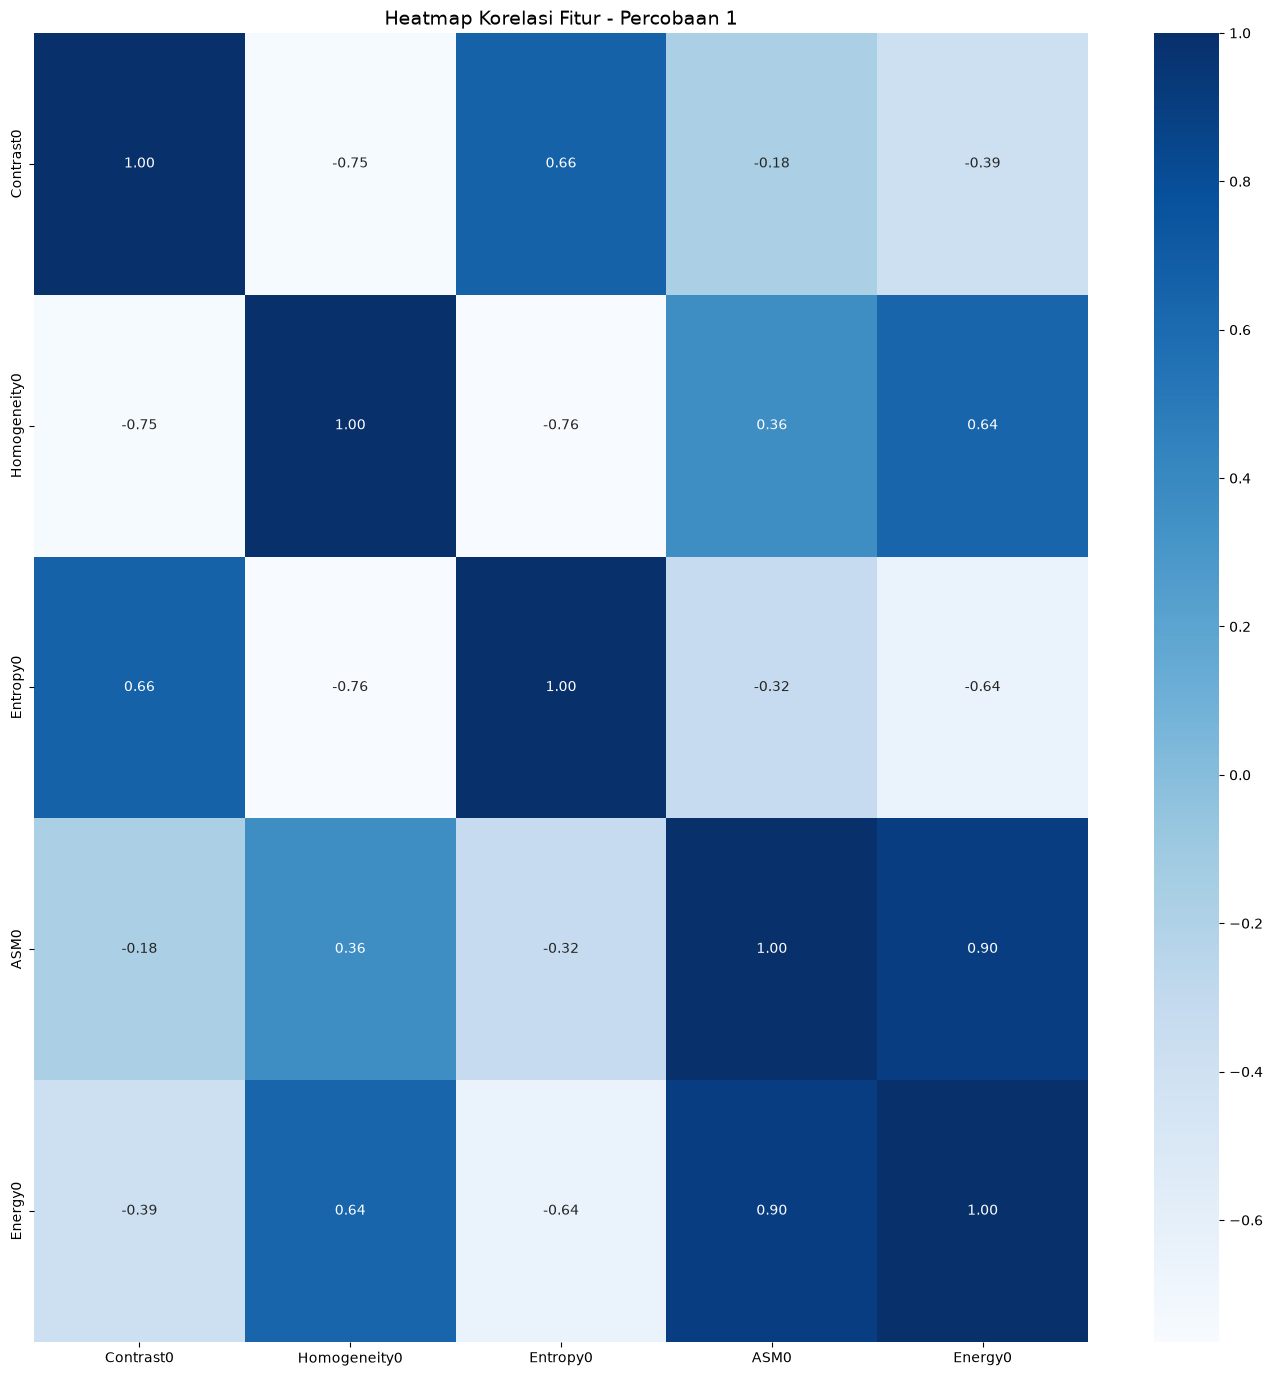

In [20]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}")
print(f"Fitur setelah seleksi: {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 1', fontsize=14)
plt.show()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (360, 5)
X_test shape:  (90, 5)


In [23]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

In [25]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))
    
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [26]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.91      0.97      0.94        66
Cassava___brown_streak_disease       0.90      0.92      0.91        75
        Cassava___green_mottle       0.90      0.90      0.90        78
             Cassava___healthy       0.91      0.93      0.92        73
      Cassava___mosaic_disease       0.97      0.85      0.91        68

                      accuracy                           0.91       360
                     macro avg       0.92      0.91      0.91       360
                  weighted avg       0.92      0.91      0.91       360

[[64  2  0  0  0]
 [ 2 69  2  2  0]
 [ 2  3 70  1  2]
 [ 1  1  3 68  0]
 [ 1  2  3  4 58]]
Accuracy: 0.9138888888888889

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.50      0.33      0.40        24
Cassava___brown_streak_disease    

In [27]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.58      0.27      0.37        66
Cassava___brown_streak_disease       0.33      0.53      0.40        75
        Cassava___green_mottle       0.37      0.36      0.36        78
             Cassava___healthy       0.57      0.27      0.37        73
      Cassava___mosaic_disease       0.37      0.51      0.43        68

                      accuracy                           0.39       360
                     macro avg       0.44      0.39      0.39       360
                  weighted avg       0.44      0.39      0.39       360

[[18 23 11  5  9]
 [ 2 40 15  4 14]
 [ 4 19 28  4 23]
 [ 5 26  8 20 14]
 [ 2 15 14  2 35]]
Accuracy: 0.39166666666666666

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.33      0.17      0.22        24
Cassava___brown_streak_disease  

In [28]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.42      0.56      0.48        66
Cassava___brown_streak_disease       0.49      0.65      0.56        75
        Cassava___green_mottle       0.53      0.50      0.52        78
             Cassava___healthy       0.62      0.42      0.50        73
      Cassava___mosaic_disease       0.52      0.38      0.44        68

                      accuracy                           0.51       360
                     macro avg       0.52      0.50      0.50       360
                  weighted avg       0.52      0.51      0.50       360

[[37 10  4  8  7]
 [15 49  5  3  3]
 [10 13 39  6 10]
 [13 16  9 31  4]
 [13 11 16  2 26]]
Accuracy: 0.5055555555555555

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.37      0.42      0.39        24
Cassava___brown_streak_disease   

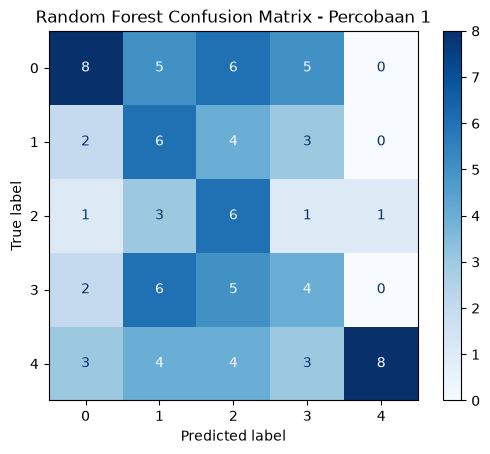

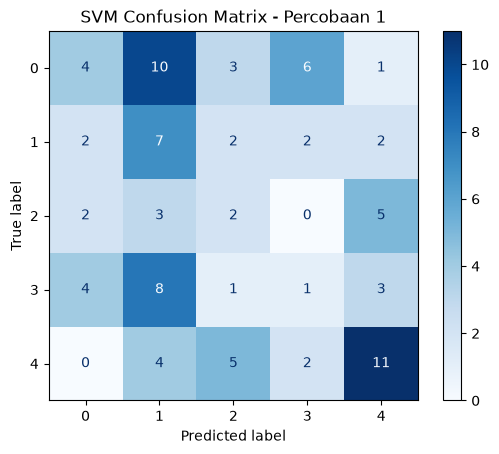

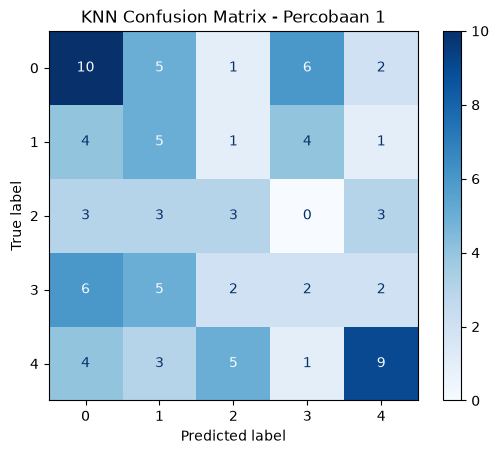

In [29]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 1")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 1")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 1")

In [32]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./Hasil_klasifikasi/hasil_klasifikasi_Percobaan1.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.913889,0.355556,0.471506,0.355556,0.373148
1,SVM,0.391667,0.277778,0.285254,0.277778,0.265952
2,KNN,0.505556,0.322222,0.330253,0.322222,0.322210
